# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [1]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [2]:
# REEMPLAZAR CON ÚLTIMOS 4 DÍGITOS DE SU CÉDULA
MI_SEMILLA = 9866  # ← cambiar aquí

# Validación: no dejen 0000
assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")

Semilla personal configurada: 9866


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [19]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# COMPLETAR: carguen el dataset, muestren shape, head, dtypes, nulos
df = pd.read_csv(url)

display(df.head())
print("-"*10)

print(f"Dimensiones (Filas/Columnas):\n{df.shape}")
print("-"*10)

print(f"Tipos:\n{df.dtypes}")
print("-"*10)

print(f"Verificación de Nulos por Columna:\n{df.isnull().sum()}")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


----------
Dimensiones (Filas/Columnas):
(891, 12)
----------
Tipos:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
----------
Verificación de Nulos por Columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

In [ ]:
# 1.2 EDA — completen aquí
# (use tantas celdas de código como necesite, pero comente cada decisión)

In [ ]:
# 1. Calculamos la tasa de supervivencia obteniendo el promedio de la columna "Survived"
tasa_supervivencia = df['Survived'].mean()
print(f"Tasa base de supervivencia: {tasa_supervivencia:.2%}")

# 2. Utilizmos la función value_counts para visualizar la distribución de variables 
# dónde 1 indica que sobrevivió y 0 indica que no sobrevivió
print("\nDistribución absoluta de la variable objetivo:")
print(df['Survived'].value_counts())

Tasa base de supervivencia: 38.38%

Distribución absoluta de la variable objetivo:
Survived
0    549
1    342
Name: count, dtype: int64


### Explicación
Según se ha investigado, no existe un umbral específico para determinar si un dataset se encuentra totalmente desbalanceado; no obstante, según esta entrada en un [foro](https://datascience.stackexchange.com/questions/122571/determining-whether-a-dataset-is-imbalanced-or-not), si la clase minoritaria representa menos del 20% del dataset se puede determinar que el conjunto de datos se encuentra imbalanceado. En este caso, el 38.38% de la clase minoritaria (sobrevió) indica un ligero desbalance pero no representativo para aplicar otras técnicas indicadas.

In [25]:
# Calculamos la cantidad de nulos mediante la función "isnull"
nulos_cantidad = df.isnull().sum()

# Calculamos la proporción de los nulos utilizando la media del dataset
nulos_porcentaje = df.isnull().mean() * 100

# Elaboramos un dataframe que nos permita visualizar los cálculos realizados
df_nulos = pd.DataFrame({'Nulos': nulos_cantidad, 'Porcentaje (%)': nulos_porcentaje})

# Imprimimos las columnas de nulos que son mayores a cero
print(df_nulos[df_nulos['Nulos'] > 0])

          Nulos  Porcentaje (%)
Age         177       19.865320
Cabin       687       77.104377
Embarked      2        0.224467


### Explicación
Age (~19.87%): Esta característica debe imputarse ya que la edad es una característica demográfica clave para la prioridad de rescate por si un pasajero es un niño.

Cabin (~77.10%): Debe eliminarse debido a que falta un tercio de los datos; por lo que imputarla generaría demasiado ruido aleatorio.

Embarked (~0.22%): En este caso hacen falta 2 registros. Esto se puede imputar con la moda (ej. el puerto más frecuente) sin generar ruido que afecte al modelo.

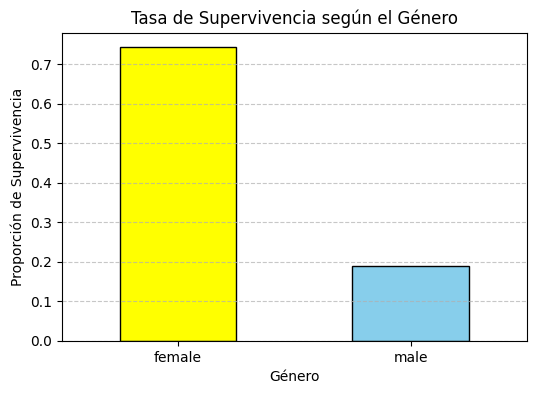

In [27]:
# Agrupamos por sexo la clasificación de supervivencia y obtenemos la media de este cálculo
supervivencia_por_sexo = df.groupby('Sex')['Survived'].mean()

# Creamos un gráfico de barras
# Establecemos un tamaño para la figura
plt.figure(figsize=(6, 4))
supervivencia_por_sexo.plot(kind='bar', color=['yellow', 'skyblue'], edgecolor='black')
plt.title('Tasa de Supervivencia según el Género')
plt.ylabel('Proporción de Supervivencia')
plt.xlabel('Género')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explicación
En la gráfica se puede observar una tendencia de supervivencia mayor en las mujeres. En este caso, aproximadamente más del 70% de las mujeres sobrevivió comparado con menos del 20% para los hombres. Esto desmuestra cómo se aplicó la regla de "mujeres y niños primero" dentro de la emergencia en el barco.

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [28]:
# --- PASO 1: Eliminar columnas que no aportan información ---
# Justificación: Las columnas correspondientes a IDs, nombres y tickets son identificadores únicos.
# Por lo tanto esto es ruido, lo eliminamos. 
# Además, cabin tiene casi el 80% de valores nulos.

# Generamos una lista con las columnas que deseamos eliminar
columnas_a_eliminar = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_limpio = df.drop(columns=columnas_a_eliminar)

# Separar características (X) y variable objetivo (y)
X = df_limpio.drop(columns=['Survived'])
y = df_limpio['Survived']


# --- PASO 2: División de datos ---
# Separamos el 20% para Test y el 80% restante de forma temporal
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=9866, stratify=y
)

# Del 80% temporal dividido antes, separamos el 25% para Validación (que equivale al 20% del total original)
# 0.80 * 0.25 = 0.20 (Validación). El 60% se utiliza en Entrenamiento.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=9866, stratify=y_temp
)

print(f"Tamaño Entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño Validación:  {X_val.shape[0]} filas")
print(f"Tamaño Test:        {X_test.shape[0]} filas\n")


# --- PASO 3: Imputación de Datos ---
# Imputamos 'Embarked' con la moda calculada dentro en el training set
moda_embarked = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(moda_embarked)
X_val['Embarked'] = X_val['Embarked'].fillna(moda_embarked)
X_test['Embarked'] = X_test['Embarked'].fillna(moda_embarked)

# Imputación de 'Age': calculamos las medianas por grupo dentro en el training set
medianas_edad_grupo = X_train.groupby(['Pclass', 'Sex'])['Age'].median()

# Función auxiliar para aplicar las medianas calculadas en train a cualquier subset
def imputar_edad_por_grupo(subset, medianas):
    # Hacemos una copia para evitar el SettingWithCopyWarning de pandas
    subset = subset.copy()
    # Mapeamos la combinación de Pclass y Sex para rellenar los nulos
    valores_imputacion = subset.set_index(['Pclass', 'Sex']).index.map(medianas)
    subset['Age'] = subset['Age'].fillna(pd.Series(valores_imputacion, index=subset.index))
    return subset

X_train = imputar_edad_por_grupo(X_train, medianas_edad_grupo)
X_val = imputar_edad_por_grupo(X_val, medianas_edad_grupo)
X_test = imputar_edad_por_grupo(X_test, medianas_edad_grupo)


# --- PASO 4: Codificación de Variables Categóricas mediante One-Hot Encoding ---
# Convertimos 'Sex' y 'Embarked' a columnas numéricas (0 y 1)
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_val = pd.get_dummies(X_val, columns=['Sex', 'Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True)

# Establecemos que tres conjuntos tengan exactamente las mismas columnas después del encoding
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


# --- PASO 5: Escalado de Características Numéricas (StandardScaler) ---
features_numéricas = ['Age', 'SibSp', 'Parch', 'Fare']
scaler = StandardScaler()

# Ajustamos el escalador dentro de los datos de entrenamiento
X_train[features_numéricas] = scaler.fit_transform(X_train[features_numéricas])

# Transformamos validación y test con el escalador ya ajustado (SIN volver a hacer .fit)
X_val[features_numéricas] = scaler.transform(X_val[features_numéricas])
X_test[features_numéricas] = scaler.transform(X_test[features_numéricas])

print("¡Preprocesamiento completado con éxito sin Data Leakage!")

Tamaño Entrenamiento: 534 filas
Tamaño Validación:  178 filas
Tamaño Test:        179 filas

¡Preprocesamiento completado con éxito sin Data Leakage!


## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [29]:
# 1. Instanciamos la Regresión Logística con parámetros por defecto
# Nota: Establecemos un random state para asegurar la reproducibilidad.
baseline_model = LogisticRegression(random_state=9866)

# 2. Entrenar el modelo SÓLO con el conjunto de entrenamiento
baseline_model.fit(X_train, y_train)

# 3. Calcular las predicciones para ambos conjuntos
y_train_pred = baseline_model.predict(X_train)
y_val_pred = baseline_model.predict(X_val)

# 4. Calcular el Accuracy
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)

print(f"Accuracy en el conjunto de Entrenamiento (Train): {accuracy_train:.4f}")
print(f"Accuracy en el conjunto de Validación (Val):     {accuracy_val:.4f}")

Accuracy en el conjunto de Entrenamiento (Train): 0.8184
Accuracy en el conjunto de Validación (Val):     0.7809


## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [30]:
# 1. Definir la malla de hiperparámetros (Parámetros requeridos en la rúbrica)
# Usamos 5 valores en escala logarítmica para C entre 0.001 y 100
param_grid = {
    'C': np.logspace(-3, 2, 5),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# 2. Instanciar el modelo base
base_model = LogisticRegression(random_state=MI_SEMILLA, max_iter=5000)

# 3. Configurar el GridSearchCV sobre el TRAINING SET
# Elegimos 'f1' como métrica de optimización en lugar del accuracy por defecto
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 4. Ajustar el GridSearch ÚNICAMENTE en el training set
grid_search.fit(X_train, y_train)

# 5. Obtener el mejor modelo entrenado
best_model = grid_search.best_estimator_

# 6. Evaluar el score en el conjunto de VALIDACIÓN
y_val_pred_best = best_model.predict(X_val)
f1_val_score = f1_score(y_val, y_val_pred_best)

print("=================== RESULTADOS DEL GRIDSEARCH ===================")
print(f"1. Mejor combinación de hiperparámetros: {grid_search.best_params_}")
print(f"2. Mejor score de CV (F1-Score promedio): {grid_search.best_score_:.4f}")
print(f"3. F1-Score final sobre el Validation Set:   {f1_val_score:.4f}")
print("=================================================================")

=================== RESULTADOS DEL GRIDSEARCH ===================
1. Mejor combinación de hiperparámetros: {'C': np.float64(100.0), 'penalty': 'l1', 'solver': 'liblinear'}
2. Mejor score de CV (F1-Score promedio): 0.7389
3. F1-Score final sobre el Validation Set:   0.7194


## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

================ MÉTRICAS SOBRE VALIDACIÓN ================
Accuracy:  0.7809
Precision: 0.7042
Recall:    0.7353
F1-Score:  0.7194
ROC-AUC:   0.8370



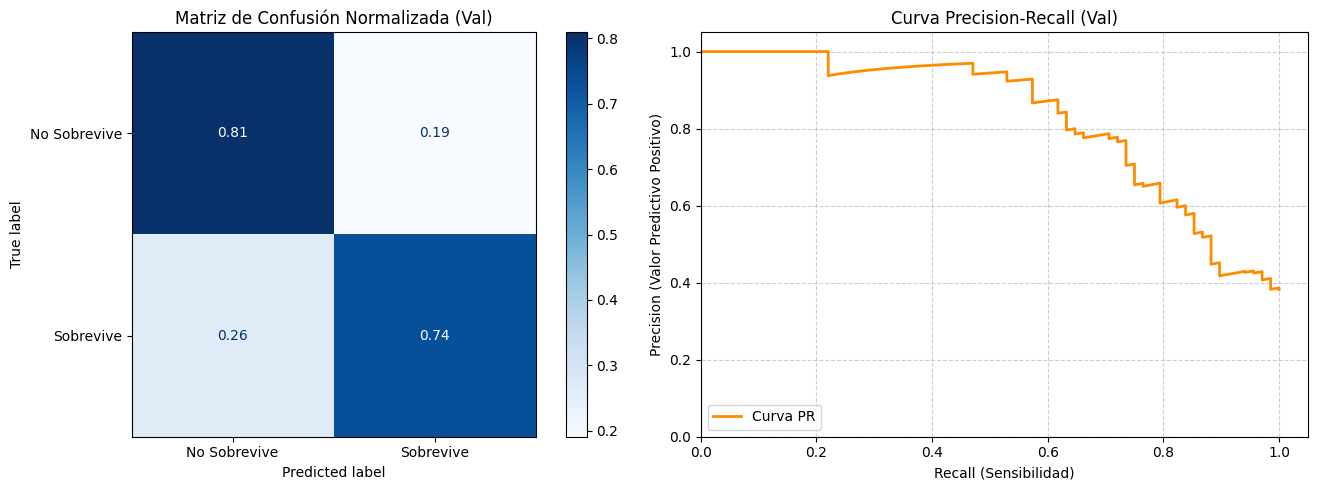

In [31]:
# 1. Obtener predicciones de clase y probabilidades del mejor modelo
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

# 2. Calcular las 5 métricas requeridas
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_proba)

print("================ MÉTRICAS SOBRE VALIDACIÓN ================")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc_auc:.4f}")
print("===========================================================\n")

# 3. Graficar Matriz de Confusión Normalizada
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_val, y_val,
    display_labels=["No Sobrevive", "Sobrevive"],
    normalize='true',  # Normalizada por filas (valores reales)
    cmap='Blues',
    ax=ax[0]
)
ax[0].set_title("Matriz de Confusión Normalizada (Val)")

# 4. Calcular y graficar la Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

ax[1].plot(recalls, precisions, color='darkorange', lw=2, label='Curva PR')
ax[1].set_xlabel('Recall (Sensibilidad)')
ax[1].set_ylabel('Precision (Valor Predictivo Positivo)')
ax[1].set_title('Curva Precision-Recall (Val)')
ax[1].set_xlim([0.0, 1.05])
ax[1].set_ylim([0.0, 1.05])
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

En este caso, la aseguradora es una empresa que prioriza una estabilidad que minimiza siniestros al establecer una prima de seguros altas. En este caso, se establece que es una empresa emergente que no contiene muchas reservas en caso de que varios pasajeros fallezcan; por lo tanto, la empresa minimiza los riegos mediante una técnica llamada Price Skimming para establecer un precio que limite sus clientes iniciales debido a la singularidad de su plan de seguros en un barco.

Por otro lado, se prioriza la precisión del modelo. Desde la perspectiva del negocio, cometer un error de tipo Falso Positivo; es decir, clasificar de forma optimista a un pasajero de alto riesgo como sobreviviente y cobrarle una prima baja representaría un golpe devastador para la viabilidad de la startup, ya que obligaría a desembolsar indemnizaciones totales habiendo recaudado un fondo de cobertura marginal. Al priorizar de forma drástica la precisión por encima de cualquier otra métrica, garantizamos que el algoritmo minimice al máximo la posibilidad de otorgar tarifas baratas por error a perfiles de riesgo.

En este caso, un umbral de decisíon debería ser mayor a 0.5; aproximadamente un 0.6 a 0.75 ya que se debe ser estricto con las clasificaciones sobre un pasajero con un perfil de riesgo. Al elevar el límite del modelo, este se vuelve existente para determinar una clasificación, así que esto es positivo para la empesa ya que se reducirá la mayoría de entrada d eclientes comunes, asegurando escazas indemnizaciones para mantener las operaciones de la empresa.

=== EVALUACIÓN FINAL DEFINITIVA SOBRE EL TEST SET (Umbral: 0.6) ===
Accuracy Final:  0.7989
Precision Final: 0.7895  <-- ¡Métrica priorizada por TravelSafe!
Recall Final:    0.6522
F1-Score Final:  0.7143
ROC-AUC Final:   0.8769



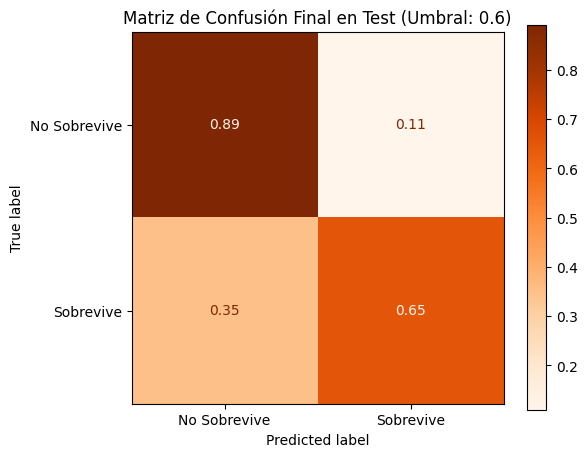

In [32]:

# 1. Definir el umbral estratégico seleccionado en el análisis (Perfil Conservador)
UMBRAL_ESTRATEGICO = 0.60

# 2. Obtener las probabilidades de la clase positiva (1: Sobrevive) en el TEST SET
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# 3. Aplicar el nuevo umbral para determinar las predicciones de clase finales
# Si la probabilidad es mayor o igual al umbral es 1, de lo contrario es 0
y_test_pred_ajustado = (y_test_proba >= UMBRAL_ESTRATEGICO).astype(int)

# 4. Calcular las métricas finales sobre el Test Set con el nuevo umbral
test_accuracy = accuracy_score(y_test, y_test_pred_ajustado)
test_precision = precision_score(y_test, y_test_pred_ajustado)
test_recall = recall_score(y_test, y_test_pred_ajustado)
test_f1 = f1_score(y_test, y_test_pred_ajustado)
test_roc_auc = roc_auc_score(y_test, y_test_proba)  # El AUC-ROC no cambia porque usa las probabilidades directas

print(f"=== EVALUACIÓN FINAL DEFINITIVA SOBRE EL TEST SET (Umbral: {UMBRAL_ESTRATEGICO}) ===")
print(f"Accuracy Final:  {test_accuracy:.4f}")
print(f"Precision Final: {test_precision:.4f}  <-- ¡Métrica priorizada por TravelSafe!")
print(f"Recall Final:    {test_recall:.4f}")
print(f"F1-Score Final:  {test_f1:.4f}")
print(f"ROC-AUC Final:   {test_roc_auc:.4f}")
print("===============================================================================\n")

# 5. Graficar la Matriz de Confusión Final resultante de este umbral estratégico
cm_final = confusion_matrix(y_test, y_test_pred_ajustado, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["No Sobrevive", "Sobrevive"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Oranges', ax=ax)
ax.set_title(f"Matriz de Confusión Final en Test (Umbral: {UMBRAL_ESTRATEGICO})")
plt.show()

---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [ ]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

**🔍 Su análisis del bug 2.1:**

*[¿Cuál es el bug? ¿Por qué es un problema? ¿Qué impacto tiene en producción?]*

In [ ]:
# Versión corregida de la celda 2.1 — completen aquí


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [ ]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

**🔍 Su análisis del bug 2.2:**

*[¿Cuál es el bug? ¿Cómo se manifiesta? ¿Qué consecuencia tiene en métricas reales?]*

In [ ]:
# Versión corregida de la celda 2.2 — completen aquí


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

*[¿Qué imprime? ¿Por qué?]*

In [ ]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [ ]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

**🔍 Su análisis del bug 2.4:**

*[¿Por qué 95% de accuracy es engañoso aquí? ¿Qué métrica deberían usar? ¿Qué pasa si entreno un modelo que SIEMPRE predice clase 0?]*

In [ ]:
# Versión corregida de la celda 2.4 — completen aquí


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.5:**

*[¿Qué pasa al ejecutar esto? Si crashea, ¿qué error? Si imprime algo, ¿qué?]*

In [ ]:
# === CELDA 2.5 — Predict the output ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0
idx = np.where(recall[:-1] >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"Threshold óptimo: {optimal_threshold}")

---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Su análisis:**

*[completar]*

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Su análisis:**

*[completar]*

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Su análisis:**

*[completar]*

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 |  |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 |  |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 |  |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 |  |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 |  |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 |  |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 |  |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 |  |
| **Subtotal Parte 1** | **1.50** |  |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 |  |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 |  |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 |  |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 |  |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 |  |
| **Subtotal Parte 2** | **0.75** |  |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 |  |
| 3.2 Análisis recomendador streaming | 0.25 |  |
| 3.3 Análisis triage neumonía | 0.25 |  |
| **Subtotal Parte 3** | **0.75** |  |

---

## NOTA TOTAL: _____ / 3.0

---

## Declaración de honestidad académica

*Yo, **Sebastián Rafael Aucapiña Valdivieso**, con cédula **1750129866**, declaro que:*

1. *La semilla `9866` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** Sebastián Rafael Aucapiña Valdivieso

**Fecha y hora de finalización:** ___________________________

---

## Checklist antes de hacer push final

- [x] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [ ] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [ ] Hice commit con mensaje claro de cada parte completada
- [ ] La auto-rúbrica está completa y firmada
- [ ] Hice `git push origin eval-titanic`